# Considerations for categorical data

## Why perform EDA?
- Detect patterns and relationships
- Generate hypotheses
- Prepare data for machine learning
- Data must be representative

## Categorical classes
- Classes = labels
- Need to watch for class imbalance -> Ex. if a survey about views on marriage contains a disproportionate number of divorced people
- Reminder: use `df['col'].value_counts()` to count number of observations per class

### Relative class frequency
- Use `df['col'].value_counts(normalize=True)` to get relative frequency distribution

## Cross-tabulation
- Examine the frequency of combinations of classes using `pd.crosstab()`
- Call `pd.crosstab()` -> Select column for index -> select columns (values will be frequencies)


In [13]:
import pandas as pd
planes = pd.read_csv("../datasets/planes.csv",parse_dates=["Date_of_Journey"],date_format='%d/%m/%Y')
print(planes.dtypes)
pd.crosstab(planes["Source"], planes["Destination"])

Airline                       str
Date_of_Journey    datetime64[us]
Source                        str
Destination                   str
Route                         str
Dep_Time                      str
Arrival_Time                  str
Duration                      str
Total_Stops                   str
Additional_Info               str
Price                     float64
dtype: object


Destination,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
Source,,,,,,
Banglore,0,0,1199,0,0,868
Chennai,0,0,0,0,364,0
Delhi,0,4318,0,0,0,0
Kolkata,2720,0,0,0,0,0
Mumbai,0,0,0,662,0,0


## Aggregated values with pd.crosstab()
- add `values=...` and `aggfunc=` kwargs to `pd.crosstab()`

In [3]:
pd.crosstab(planes["Source"],planes["Destination"],values=planes["Price"], aggfunc="median")

Destination,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
Source,,,,,,
Banglore,NaN,NaN,4823.0,NaN,NaN,10976.5
Chennai,NaN,NaN,NaN,NaN,3850.0,NaN
Delhi,NaN,10262.0,NaN,NaN,NaN,NaN
Kolkata,9345.0,NaN,NaN,NaN,NaN,NaN
Mumbai,NaN,NaN,NaN,3342.0,NaN,NaN


Say we want something like this...

|Experience\Size| L | M | S |
|-|-|-|-|
|Data Analytics| Mean Salary for Data Analytics at Large Companies | Mean for DA at M companies | Mean for DA at S companies |
|DE | . | . | . |

In [6]:
salaries = pd.read_csv("../datasets/ds_salaries_clean.csv")
pd.crosstab(salaries["Experience"],salaries["Company_Size"],values=salaries["Salary_USD"],aggfunc="median")

Company_Size,L,M,S
Experience,,,
Entry,60948.0,47573.0,57290.0
Executive,188082.0,163694.5,112849.0
Mid,82116.0,75105.5,54175.0
Senior,140360.5,129380.0,103698.5


# Generating new features

- Ex. in the planes dataset, total_stops should really be numeric

In [15]:
print(planes["Total_Stops"].value_counts())

Total_Stops
1 stop      5503
non-stop    3411
2 stops     1488
3 stops       45
4 stops        1
Name: count, dtype: int64


In [44]:
planes["Total_Stops"] = planes["Total_Stops"].str.replace("non-stop", "0")
print(planes["Total_Stops"].value_counts())
planes["Total_Stops_int"] = planes["Total_Stops"].str.replace(" stops","").str.replace(" stop", "").dropna()
planes["Total_Stops_int"] = pd.to_numeric(planes["Total_Stops"].str.replace(" stops","").str.replace(" stop", ""), errors='coerce')
print(planes["Total_Stops_int"].astype('Int64').value_counts())

Total_Stops
1 stop     5503
0 stops    3411
2 stops    1488
3 stops      45
4 stops       1
Name: count, dtype: int64
Total_Stops_int
1    5503
0    3411
2    1488
3      45
4       1
Name: count, dtype: Int64


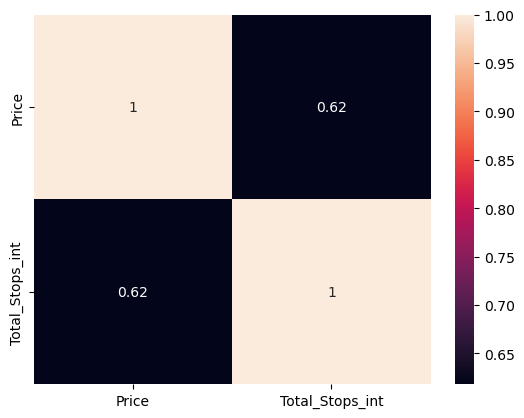

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(planes.corr(numeric_only=True),annot=True)
plt.show()

Useful note: use `dt.weekday` to get the day of the week for a date

## Getting categories from descriptive statistics
- use `pd.cut()` to bin continuous data into intervals
    - Call `pd.cut()` -> pass the data -> set the labels -> provide the bins

In [48]:
planes.describe()

,Date_of_Journey,Price,Total_Stops_int
count,10338,10044.000000,10448.000000
mean,2019-05-05 00:00:00,9044.411191,0.824847
min,2019-03-01 00:00:00,1759.000000,0.000000
25%,2019-03-27 00:00:00,5276.750000,0.000000
50%,2019-05-15 00:00:00,8366.000000,1.000000
75%,2019-06-06 00:00:00,12373.000000,1.000000
max,2019-06-27 00:00:00,54826.000000,4.000000
std,NaN,4472.304869,0.675535


In [ ]:
# Find quantiles
q1 = planes["Price"].quantile(0.25)
med = planes["Price"].median()
q3 = planes["Price"].quantile(0.75)
maximum = planes["Price"].max()

# Create labels and bins
labels = ["Economy", "Premium Economy", "Business Class", "First Class"]
bins = [0, q1, med, q3, maximum]

# Bin data
planes["Price_Category"] = pd.cut(planes["Price"], labels=labels, bins=bins)

# Preview planes dataset
print(planes[["Price", "Price_Category"]].head())

     Price   Price_Category
0  13882.0      First Class
1   6218.0  Premium Economy
2  13302.0      First Class
3   3873.0          Economy
4  11087.0   Business Class


Show price category by airline using `sns.countplot`

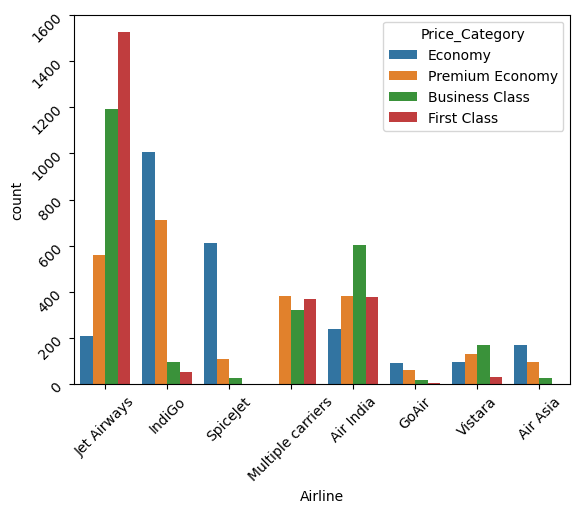

In [55]:
sns.countplot(data=planes, x="Airline", hue="Price_Category")
plt.tick_params(rotation=45)
plt.show()